 Face     O       E   (O-E)^2/E
    1    25    20.0       1.250
    2    17    20.0       0.450
    3    15    20.0       1.250
    4    23    20.0       0.450
    5    24    20.0       0.800
    6    16    20.0       0.800

Chi-square statistic = 5.0000
Degrees of freedom   = 5
Chi-square critical  = 11.0705
p-value              = 0.4159

Decision: Fail to reject H0 -> The die is fair; differences are due to chance.


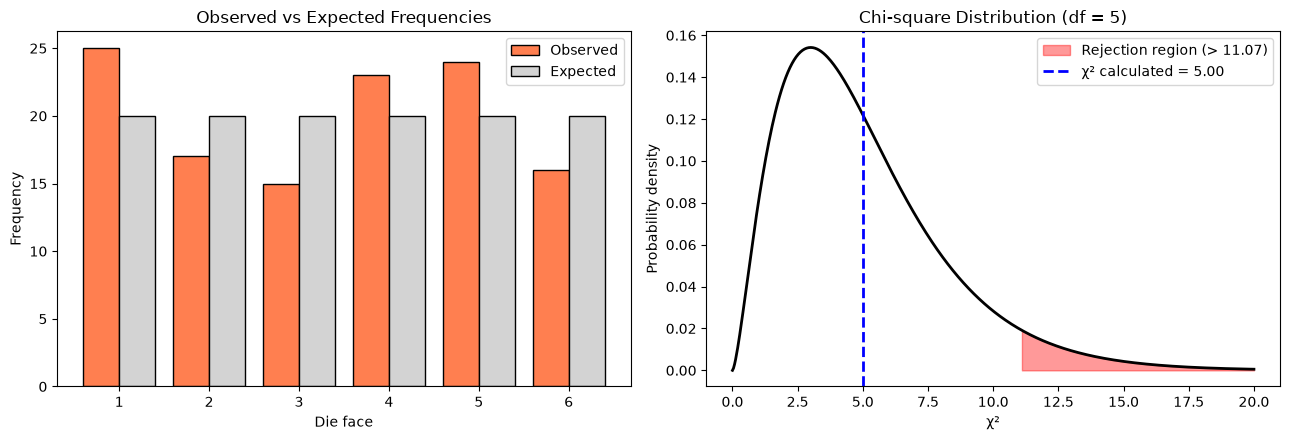

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Step 1: Data
faces = ['1', '2', '3', '4', '5', '6']

observed = np.array([25, 17, 15, 23, 24, 16])

expected = np.array([sum(observed) / 6] * 6)

alpha = 0.05

# Step 2: Calculation table
print(f"{'Face':>5}{'O':>6}{'E':>8}{'(O-E)^2/E':>12}")

for f, o, e in zip(faces, observed, expected):
    contribution = (o - e) ** 2 / e
    print(f"{f:>5}{o:>6}{e:>8.1f}{contribution:>12.3f}")

# Step 3: Chi-square test
chi2_stat, p_value = stats.chisquare(
    f_obs=observed,
    f_exp=expected
)

df = len(observed) - 1

chi2_critical = stats.chi2.ppf(
    1 - alpha,
    df
)

print(f"\nChi-square statistic = {chi2_stat:.4f}")
print(f"Degrees of freedom   = {df}")
print(f"Chi-square critical  = {chi2_critical:.4f}")
print(f"p-value              = {p_value:.4f}")

# Step 4: Decision
if p_value < alpha:
    print(
        "\nDecision: Reject H0 -> "
        "The die is biased."
    )
else:
    print(
        "\nDecision: Fail to reject H0 -> "
        "The die is fair; differences are due to chance."
    )

# Step 5: Graphs
fig, ax = plt.subplots(
    1,
    2,
    figsize=(13, 4.5)
)

# Graph 1: Observed vs Expected
x = np.arange(6)

ax[0].bar(
    x - 0.2,
    observed,
    width=0.4,
    label='Observed',
    color='coral',
    edgecolor='black'
)

ax[0].bar(
    x + 0.2,
    expected,
    width=0.4,
    label='Expected',
    color='lightgray',
    edgecolor='black'
)

ax[0].set_xticks(x)
ax[0].set_xticklabels(faces)

ax[0].set_title(
    'Observed vs Expected Frequencies'
)

ax[0].set_xlabel('Die face')
ax[0].set_ylabel('Frequency')

ax[0].legend(loc='upper right')

# Graph 2: Chi-square distribution
xc = np.linspace(
    0,
    20,
    500
)

yc = stats.chi2.pdf(
    xc,
    df
)

ax[1].plot(
    xc,
    yc,
    'k',
    lw=2
)

ax[1].fill_between(
    xc,
    yc,
    where=(xc >= chi2_critical),
    color='red',
    alpha=0.4,
    label=f'Rejection region (> {chi2_critical:.2f})'
)

ax[1].axvline(
    chi2_stat,
    color='blue',
    linestyle='--',
    lw=2,
    label=f'χ² calculated = {chi2_stat:.2f}'
)

ax[1].set_title(
    f'Chi-square Distribution (df = {df})'
)

ax[1].set_xlabel('χ²')
ax[1].set_ylabel('Probability density')

ax[1].legend(loc='upper right')

plt.tight_layout()
plt.show()